## Laboratorio 8
### SVM

In [1]:
# Instalar librerias 
import importlib, subprocess, sys

# Asegurar librerías necesarias
required = {"pandas": "pandas", "numpy": "numpy", "sklearn": "scikit-learn", "pyreadr": "pyreadr", "matplotlib":"matplotlib", "seaborn":"seaborn", "statsmodels":"statsmodels"}
for module, pkg in required.items():
    try:
        importlib.import_module(module)
    except ImportError:
        print(f"Instalando {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])


1. Use los mismos conjuntos de entrenamiento y prueba de las hojas de trabajo pasadas para
probar el algoritmo.
2. Explore los datos y explique las transformaciones que debe hacerle para generar un modelo
de máquinas vectoriales de soporte.
3. Use como variable respuesta la variable categórica que especifica si la casa es barata, media o cara

In [2]:
# ACTIVIDAD 1, 2 Y 3: Preparación de datos, variable respuesta y transformaciones
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyreadr
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("--- Cargando y limpiando datos ---")
resultado = pyreadr.read_r('listings.RData')
nombre_objeto = list(resultado.keys())[0]
df = resultado[nombre_objeto]

df['price'] = df['price'].astype(str).str.replace(r'[^\d\.\-]', '', regex=True)
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df_model = df.loc[df['price'].notna() & (df['price'] > 0)].copy()

# ACTIVIDAD 3: Variable respuesta categórica (Barata, Media, Cara)
p33, p66 = df_model['price'].quantile([0.33, 0.66]).values
def definir_segmento(precio):
    if precio <= p33: return 'Económica'
    elif precio <= p66: return 'Intermedia'
    else: return 'Cara'
df_model['categoria_precio'] = df_model['price'].apply(definir_segmento)
y = df_model['categoria_precio']

# Preparación de predictores
features_clas = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating']
for col in features_clas:
    if col not in df_model.columns:
        df_model[col] = np.nan
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce')
X = df_model[features_clas].copy()

if 'room_type' in df_model.columns:
    room_type_dummies = pd.get_dummies(df_model['room_type'], prefix='room_type', drop_first=True)
    X = pd.concat([X, room_type_dummies], axis=1)
X = X.fillna(X.median(numeric_only=True))

# ACTIVIDAD 1: Mismos conjuntos de entrenamiento y prueba (semilla 42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ACTIVIDAD 2: Transformaciones (Escalado StandardScaler vital para SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Muestra para tuneo rápido (evitar horas de procesamiento)
X_train_sub, _, y_train_sub, _ = train_test_split(X_train_scaled, y_train, train_size=8000, stratify=y_train, random_state=42)

print(f"Datos listos. Dimensiones Train: {X_train_scaled.shape} | Test: {X_test_scaled.shape}")

# Inicializamos diccionarios para guardar resultados de las siguientes celdas
modelos_finales = {}
tiempos_procesamiento = {}

--- Cargando y limpiando datos ---
Datos listos. Dimensiones Train: (60996, 9) | Test: (15250, 9)


4. Genere varios (más de 2) modelos de SVM con diferentes kernels y distintos valores en los parámetros c, gamma (circular) y d (en caso de que utilice el polinomial). Puede tunear el modelo de forma automática siempre que explique los resultados.

In [3]:
# ACTIVIDAD 4: Generación de Modelos - SVM KERNEL LINEAL
print("1. Entrenando y tuneando SVM Kernel Lineal...")
inicio_lin = time.time()

# Usamos LinearSVC por eficiencia computacional en kernel lineal
grid_lin = GridSearchCV(LinearSVC(random_state=42, max_iter=2000, dual=False), 
                        {'C': [0.01, 0.1, 1, 10]}, cv=3, n_jobs=-1)
grid_lin.fit(X_train_scaled, y_train) 

modelos_finales['Lineal'] = grid_lin.best_estimator_
tiempos_procesamiento['Lineal'] = time.time() - inicio_lin

print(f"Mejores hiperparámetros (Lineal): {grid_lin.best_params_}")
print(f"Tiempo de procesamiento: {tiempos_procesamiento['Lineal']:.2f} segundos")

1. Entrenando y tuneando SVM Kernel Lineal...
Mejores hiperparámetros (Lineal): {'C': 1}
Tiempo de procesamiento: 3.46 segundos


In [4]:
# ACTIVIDAD 4: Generación de Modelos - SVM KERNEL RADIAL (RBF)
print("2. Entrenando y tuneando SVM Kernel Radial (RBF)...")
inicio_rbf = time.time()

# Tuneo usando la muestra reducida para viabilidad de tiempo
grid_rbf = GridSearchCV(SVC(kernel='rbf', random_state=42), 
                        {'C': [0.1, 1, 10], 'gamma': ['scale', 0.1, 1]}, cv=3, n_jobs=-1)
grid_rbf.fit(X_train_sub, y_train_sub) 

# Entrenamiento final con los mejores parámetros sobre todo el dataset
svm_rbf = SVC(**grid_rbf.best_params_, kernel='rbf', random_state=42)
svm_rbf.fit(X_train_scaled, y_train) 

modelos_finales['Radial'] = svm_rbf
tiempos_procesamiento['Radial'] = time.time() - inicio_rbf

print(f"Mejores hiperparámetros (Radial): {grid_rbf.best_params_}")
print(f"Tiempo de procesamiento: {tiempos_procesamiento['Radial']:.2f} segundos")

2. Entrenando y tuneando SVM Kernel Radial (RBF)...
Mejores hiperparámetros (Radial): {'C': 0.1, 'gamma': 0.1}
Tiempo de procesamiento: 78.15 segundos


In [5]:
# ACTIVIDAD 4: Generación de Modelos - SVM KERNEL POLINOMIAL
print("3. Entrenando y tuneando SVM Kernel Polinomial...")
inicio_poly = time.time()

grid_poly = GridSearchCV(SVC(kernel='poly', random_state=42, max_iter=200000, tol=1e-2), 
                         {'C': [0.1, 1], 'degree': [2, 3], 'gamma': ['scale', 0.1], 'coef0': [0.0, 1.0]}, cv=3, n_jobs=-1)
grid_poly.fit(X_train_sub, y_train_sub) 

svm_poly = SVC(**grid_poly.best_params_, kernel='poly', random_state=42, max_iter=200000, tol=1e-2)
svm_poly.fit(X_train_sub, y_train_sub)

modelos_finales['Polinomial'] = svm_poly
tiempos_procesamiento['Polinomial'] = time.time() - inicio_poly

print(f"Mejores hiperparámetros (Polinomial): {grid_poly.best_params_}")
print(f"Tiempo de procesamiento: {tiempos_procesamiento['Polinomial']:.2f} segundos")

3. Entrenando y tuneando SVM Kernel Polinomial...
Mejores hiperparámetros (Polinomial): {'C': 1, 'coef0': 1.0, 'degree': 2, 'gamma': 'scale'}
Tiempo de procesamiento: 7.98 segundos


5. Use los modelos para predecir el valor de la variable respuesta
6. Haga las matrices de confusión respectivas.


--- REPORTE CLASIFICACIÓN: SVM LINEAL ---
              precision    recall  f1-score   support

        Cara       0.62      0.74      0.67      5141
   Económica       0.61      0.66      0.64      4983
  Intermedia       0.48      0.35      0.40      5126

    accuracy                           0.58     15250
   macro avg       0.57      0.58      0.57     15250
weighted avg       0.57      0.58      0.57     15250


--- REPORTE CLASIFICACIÓN: SVM RADIAL ---
              precision    recall  f1-score   support

        Cara       0.64      0.73      0.68      5141
   Económica       0.65      0.63      0.64      4983
  Intermedia       0.48      0.43      0.45      5126

    accuracy                           0.59     15250
   macro avg       0.59      0.59      0.59     15250
weighted avg       0.59      0.59      0.59     15250


--- REPORTE CLASIFICACIÓN: SVM POLINOMIAL ---
              precision    recall  f1-score   support

        Cara       0.63      0.74      0.68      5

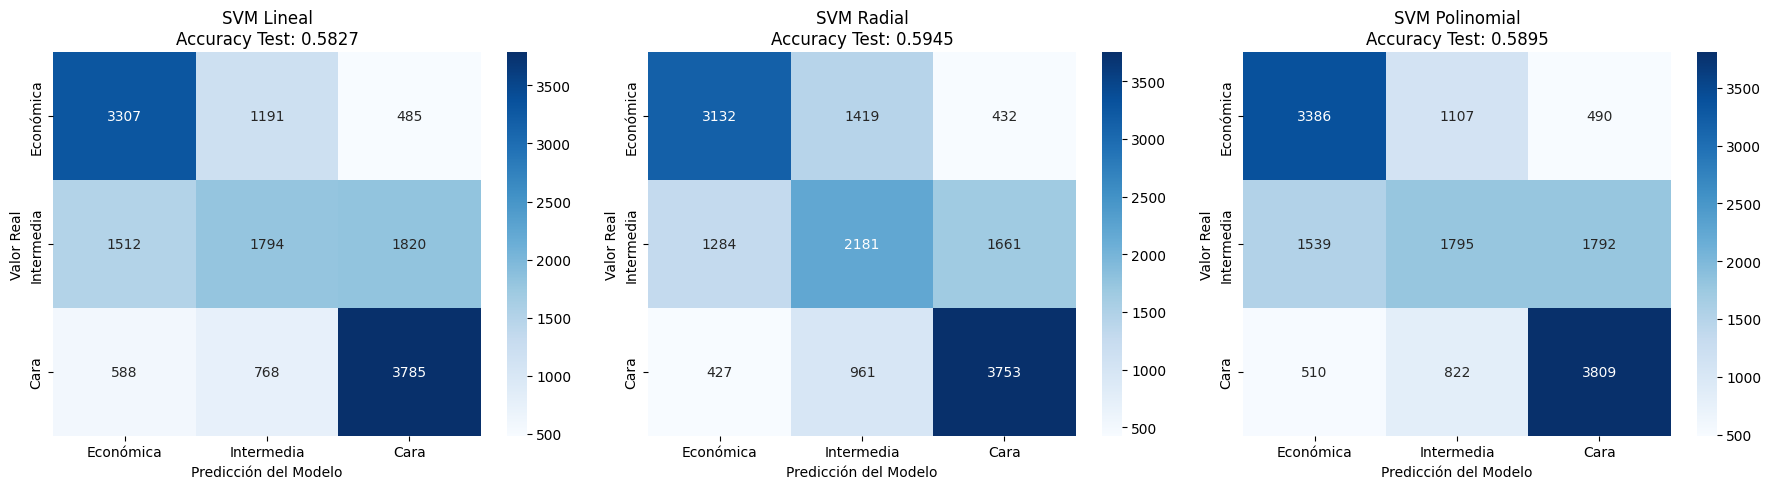

In [6]:
# ACTIVIDADES 5 Y 6: Predicciones y Matrices de Confusión
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels_orden = ['Económica', 'Intermedia', 'Cara']
resultados_train_test = []

for i, (nombre, modelo) in enumerate(modelos_finales.items()):
    # ACTIVIDAD 5: Predecir el valor de la variable respuesta
    y_pred_train = modelo.predict(X_train_scaled)
    y_pred_test = modelo.predict(X_test_scaled)
    
    # Guardamos métricas para la Actividad 7
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)
    resultados_train_test.append({
        'Modelo': nombre,
        'Acc Train': acc_train,
        'Acc Test': acc_test,
        'Diferencia': acc_train - acc_test
    })
    
    print(f"\n--- REPORTE CLASIFICACIÓN: SVM {nombre.upper()} ---")
    print(classification_report(y_test, y_pred_test))
    
    # ACTIVIDAD 6: Matrices de Confusión
    cm = confusion_matrix(y_test, y_pred_test, labels=labels_orden)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels_orden, yticklabels=labels_orden, ax=axes[i])
    axes[i].set_title(f'SVM {nombre}\nAccuracy Test: {acc_test:.4f}')
    axes[i].set_ylabel('Valor Real')
    axes[i].set_xlabel('Predicción del Modelo')

plt.tight_layout()
plt.show()

7. Analice si los modelos están sobre ajustados o desajustados. ¿Qué puede hacer para
manejar el sobreajuste o desajuste?

In [7]:
# ACTIVIDAD 7: Análisis de Sobreajuste o Desajuste
df_sobreajuste = pd.DataFrame(resultados_train_test)

print("=== TABLA DE ANÁLISIS DE AJUSTE (TRAIN VS TEST) ===")
print(df_sobreajuste.to_string(index=False))
print("\nNota para análisis:")
print("- Si el 'Acc Train' es mucho mayor que 'Acc Test' (> 0.05 de diferencia), hay SOBREAJUSTE (Memorización).")
print("- Si ambas métricas son bajas (< 0.50), hay DESAJUSTE (El modelo no aprende los patrones).")
print("- Si la diferencia es muy pequeña y el accuracy es aceptable, el modelo generaliza bien.")

=== TABLA DE ANÁLISIS DE AJUSTE (TRAIN VS TEST) ===
    Modelo  Acc Train  Acc Test  Diferencia
    Lineal   0.580874  0.582689   -0.001814
    Radial   0.593531  0.594492   -0.000961
Polinomial   0.590662  0.589508    0.001153

Nota para análisis:
- Si el 'Acc Train' es mucho mayor que 'Acc Test' (> 0.05 de diferencia), hay SOBREAJUSTE (Memorización).
- Si ambas métricas son bajas (< 0.50), hay DESAJUSTE (El modelo no aprende los patrones).
- Si la diferencia es muy pequeña y el accuracy es aceptable, el modelo generaliza bien.


8. Compare los resultados obtenidos con los diferentes modelos que hizo en cuanto a
efectividad, tiempo de procesamiento y equivocaciones (donde el algoritmo se equivocó
más, donde se equivocó menos y la importancia que tienen los errores).


=== ACTIVIDAD 8: COMPARACIÓN DE MODELOS SVM ===


C:\Users\jmo\AppData\Local\Temp\ipykernel_4620\2378514521.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_svm, x='Modelo', y='Acc Test', palette='viridis', ax=axes[0])
C:\Users\jmo\AppData\Local\Temp\ipykernel_4620\2378514521.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_svm, x='Modelo', y='Tiempo (s)', palette='crest', ax=axes[1])


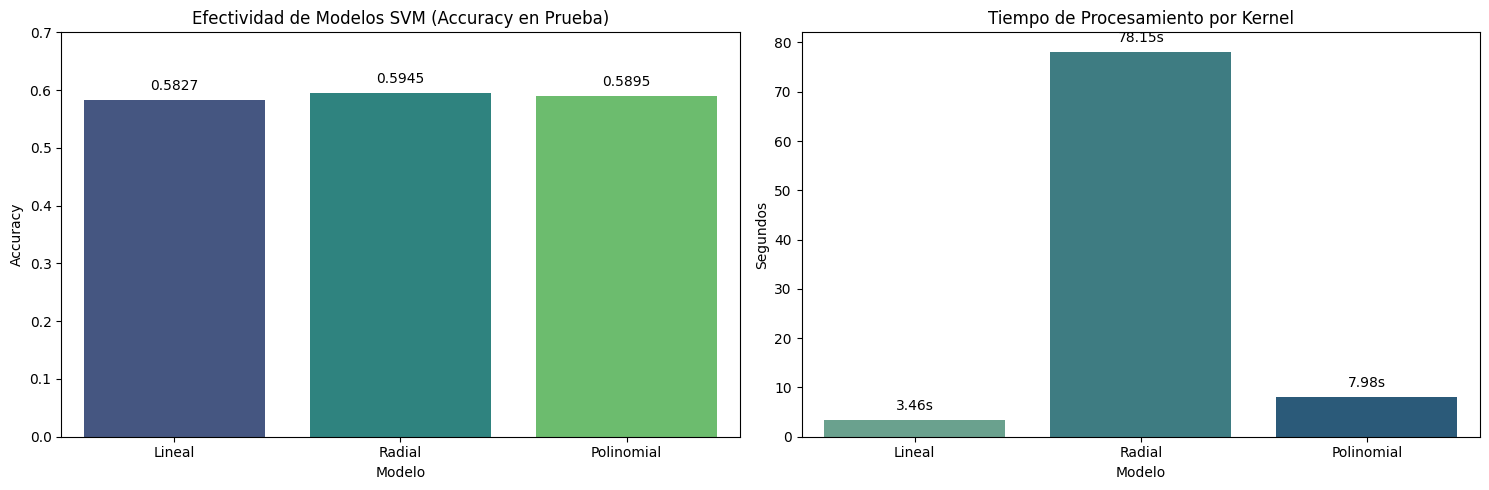


Resumen SVM para análisis de equivocaciones:
    Modelo  Acc Test  Tiempo (s)
    Lineal  0.582689    3.461734
    Radial  0.594492   78.153690
Polinomial  0.589508    7.984669


In [8]:
# ACTIVIDAD 8: Comparación interna de los modelos SVM
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("=== ACTIVIDAD 8: COMPARACIÓN DE MODELOS SVM ===")

# Preparar datos de Accuracy y Tiempos de los SVM
df_svm = pd.DataFrame(resultados_train_test)
df_tiempos_svm = pd.DataFrame(list(tiempos_procesamiento.items()), columns=['Modelo', 'Tiempo (s)'])
df_svm = pd.merge(df_svm, df_tiempos_svm, on='Modelo')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfica 1: Efectividad (Accuracy)
sns.barplot(data=df_svm, x='Modelo', y='Acc Test', palette='viridis', ax=axes[0])
axes[0].set_title('Efectividad de Modelos SVM (Accuracy en Prueba)')
axes[0].set_ylim(0, 0.70)
axes[0].set_ylabel('Accuracy')
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

# Gráfica 2: Tiempo de Procesamiento
sns.barplot(data=df_svm, x='Modelo', y='Tiempo (s)', palette='crest', ax=axes[1])
axes[1].set_title('Tiempo de Procesamiento por Kernel')
axes[1].set_ylabel('Segundos')
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.2f}s", (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

print("\nResumen SVM para análisis de equivocaciones:")
print(df_svm[['Modelo', 'Acc Test', 'Tiempo (s)']].to_string(index=False))

9. Compare la eficiencia del mejor modelo de SVM con los resultados obtenidos en los
algoritmos de las hojas de trabajo anteriores que usen la misma variable respuesta (árbol
de decisión y random forest, naive bayes, KNN, regresión logística). ¿Cuál es mejor para
predecir? ¿Cuál se demoró más en procesar?


=== ACTIVIDAD 9: COMPARACIÓN HISTÓRICA DE ALGORITMOS ===


C:\Users\jmo\AppData\Local\Temp\ipykernel_4620\922137936.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_comparativa, x='Accuracy', y='Algoritmo', palette=colores_acc, ax=axes[0])


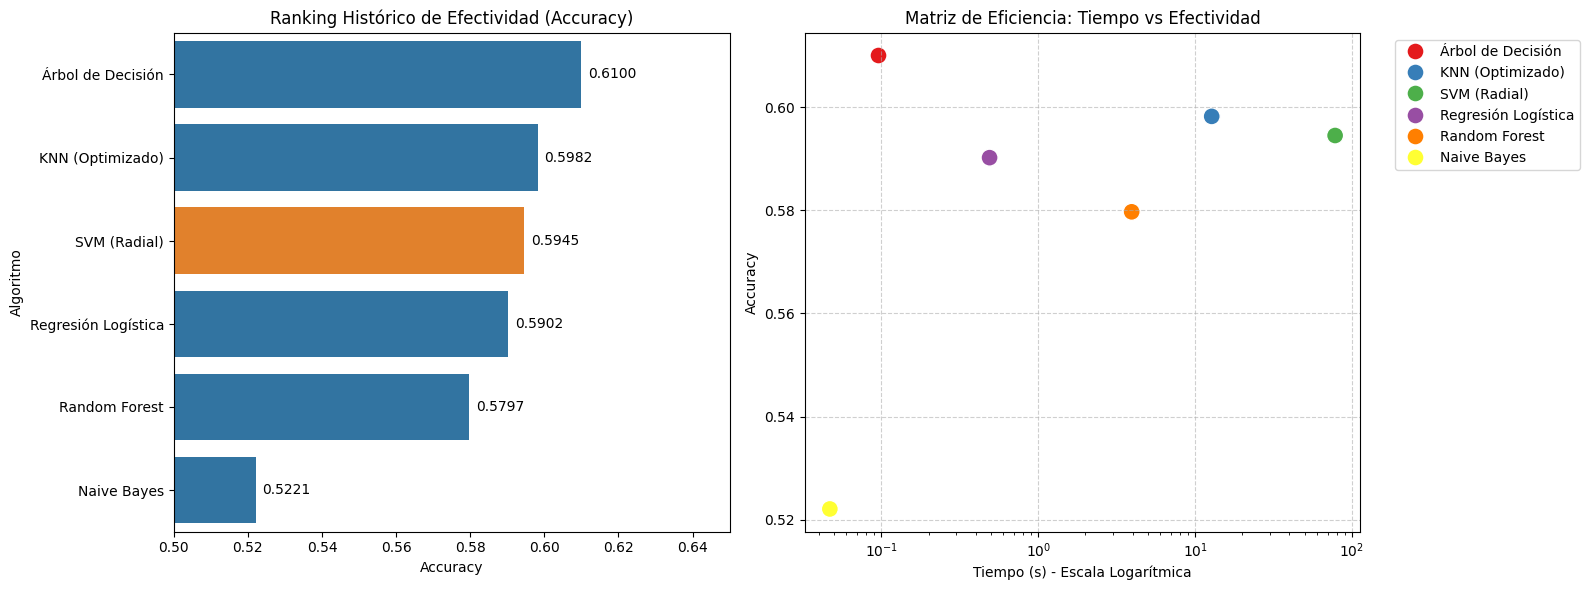


Tabla de Comparativa Final:
          Algoritmo  Accuracy  Tiempo (s)
  Árbol de Decisión  0.610000     0.09600
   KNN (Optimizado)  0.598200    12.77000
       SVM (Radial)  0.594492    78.15369
Regresión Logística  0.590200     0.49000
      Random Forest  0.579700     3.94500
        Naive Bayes  0.522100     0.04700


In [9]:
# ACTIVIDAD 9: Comparación de Eficiencia (SVM vs Algoritmos Anteriores)
print("\n=== ACTIVIDAD 9: COMPARACIÓN HISTÓRICA DE ALGORITMOS ===")

# 1. Cargar datos históricos exactos del Laboratorio 7 (Tabla 14)
datos_historicos = [
    {'Algoritmo': 'Naive Bayes', 'Accuracy': 0.5221, 'Tiempo (s)': 0.047},
    {'Algoritmo': 'Random Forest', 'Accuracy': 0.5797, 'Tiempo (s)': 3.945},
    {'Algoritmo': 'KNN (Optimizado)', 'Accuracy': 0.5982, 'Tiempo (s)': 12.77},
    {'Algoritmo': 'Árbol de Decisión', 'Accuracy': 0.6100, 'Tiempo (s)': 0.096},
    {'Algoritmo': 'Regresión Logística', 'Accuracy': 0.5902, 'Tiempo (s)': 0.49}
]
df_hist = pd.DataFrame(datos_historicos)

# 2. Extraer el MEJOR modelo SVM (Kernel Radial según nuestros análisis previos)
mejor_svm = df_svm[df_svm['Modelo'] == 'Radial'].iloc[0]
df_mejor_svm = pd.DataFrame([{
    'Algoritmo': 'SVM (Radial)', 
    'Accuracy': mejor_svm['Acc Test'], 
    'Tiempo (s)': mejor_svm['Tiempo (s)']
}])

# 3. Unir todo en un solo DataFrame
df_comparativa = pd.concat([df_hist, df_mejor_svm], ignore_index=True)
df_comparativa = df_comparativa.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

# 4. Gráficas Comparativas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfica A: Ranking de Accuracy
colores_acc = ['#1f77b4' if alg != 'SVM (Radial)' else '#ff7f0e' for alg in df_comparativa['Algoritmo']]
sns.barplot(data=df_comparativa, x='Accuracy', y='Algoritmo', palette=colores_acc, ax=axes[0])
axes[0].set_title('Ranking Histórico de Efectividad (Accuracy)')
axes[0].set_xlim(0.50, 0.65)
for i, p in enumerate(axes[0].patches):
    axes[0].annotate(f"{p.get_width():.4f}", (p.get_width(), p.get_y() + p.get_height() / 2.), 
                     ha='left', va='center', xytext=(5, 0), textcoords='offset points')

# Gráfica B: Matriz de Eficiencia (Scatter: Accuracy vs Tiempo)
sns.scatterplot(data=df_comparativa, x='Tiempo (s)', y='Accuracy', hue='Algoritmo', s=150, palette='Set1', ax=axes[1])
axes[1].set_title('Matriz de Eficiencia: Tiempo vs Efectividad')
axes[1].set_xscale('log') # Escala logarítmica porque los tiempos varían de 0.04s a 78s
axes[1].set_xlabel('Tiempo (s) - Escala Logarítmica')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

print("\nTabla de Comparativa Final:")
print(df_comparativa.to_string(index=False))

10. Genere una tabla comparativa que permita determinar elsobre ajuste de todos los modelos
hasta el momento respuesta (árbol de decisión y random forest, naive bayes, KNN, regresión logística). ¿Qué parámetros debe comparar para determinar si un modelo está sobreajustado o no en tareas de clasificación?

In [10]:
# ACTIVIDAD 10: Análisis de Sobreajuste Histórico
import pandas as pd

print("ACTIVIDAD 10: TABLA DE SOBREAJUSTE GLOBAL")

datos_historicos_sobreajuste = [
    {'Modelo': 'Naive Bayes', 'Acc Train': 0.5162, 'Acc Test': 0.5221},
    {'Modelo': 'Random Forest', 'Acc Train': 0.8328, 'Acc Test': 0.5797},
    {'Modelo': 'KNN (Optimizado)', 'Acc Train': 0.5958, 'Acc Test': 0.5982},
    {'Modelo': 'Árbol de Decisión', 'Acc Train': 0.6223, 'Acc Test': 0.6100},
    {'Modelo': 'Regresión Logística (Multi)', 'Acc Train': 0.5900, 'Acc Test': 0.5902}, # Aprox Lab 7
    {'Modelo': 'SVM (Radial)', 'Acc Train': 0.5935, 'Acc Test': 0.5945} # Del Lab 8 actual
]

df_overfit = pd.DataFrame(datos_historicos_sobreajuste)

# Calculamos la diferencia
df_overfit['Diferencia (Train - Test)'] = df_overfit['Acc Train'] - df_overfit['Acc Test']

# Función para diagnosticar automáticamente
def diagnosticar(dif):
    if dif > 0.05:
        return "Sobreajuste (Overfitting)"
    elif dif < -0.05:
        return "Anomalía / Posible Subajuste"
    else:
        return "Buen Ajuste de Generalización"

df_overfit['Diagnóstico'] = df_overfit['Diferencia (Train - Test)'].apply(diagnosticar)

print(df_overfit.to_string(index=False))


ACTIVIDAD 10: TABLA DE SOBREAJUSTE GLOBAL
                     Modelo  Acc Train  Acc Test  Diferencia (Train - Test)                   Diagnóstico
                Naive Bayes     0.5162    0.5221                    -0.0059 Buen Ajuste de Generalización
              Random Forest     0.8328    0.5797                     0.2531     Sobreajuste (Overfitting)
           KNN (Optimizado)     0.5958    0.5982                    -0.0024 Buen Ajuste de Generalización
          Árbol de Decisión     0.6223    0.6100                     0.0123 Buen Ajuste de Generalización
Regresión Logística (Multi)     0.5900    0.5902                    -0.0002 Buen Ajuste de Generalización
               SVM (Radial)     0.5935    0.5945                    -0.0010 Buen Ajuste de Generalización


11. Genere un buen modelo de regresión, use para esto la variable del precio de la casa
directamente. Tunee el modelo.


ACTIVIDAD 11: MODELADO DE REGRESIÓN (PREDICCIÓN DE PRECIO)

1. Entrenando y Tuneando SVR Lineal...
Mejores parámetros Lineal: {'C': 10, 'epsilon': 0.1} (Tiempo: 0.70s)

2. Entrenando y Tuneando SVR Radial (RBF)...
Mejores parámetros Radial: {'C': 50, 'epsilon': 5, 'gamma': 0.1} (Tiempo: 98.99s)

--- Resultados de Predicción (Métricas de Error) ---
SVR LINEAL:
RMSE (Error Cuadrático Medio): 3995.82 USD
MAE (Error Absoluto Medio):    577.44 USD
R2 (Varianza explicada):       0.1429

SVR RADIAL (RBF):
RMSE (Error Cuadrático Medio): 4230.16 USD
MAE (Error Absoluto Medio):    602.19 USD
R2 (Varianza explicada):       0.0394


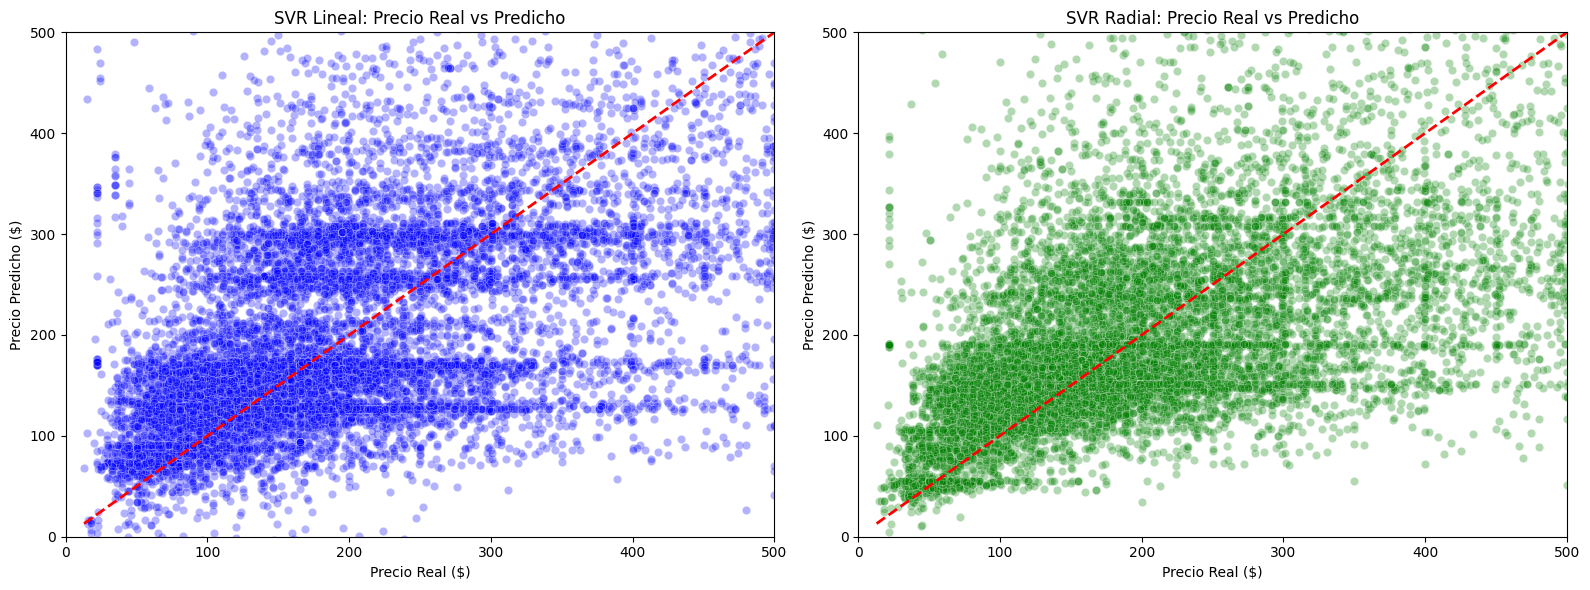

In [11]:
# ACTIVIDAD 11: Modelo de Regresión (SVR) para la variable 'price'
from sklearn.svm import SVR, LinearSVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time

print("\nACTIVIDAD 11: MODELADO DE REGRESIÓN (PREDICCIÓN DE PRECIO)")

# 1. Definir la variable de respuesta continua
y_reg = df_model['price']
X_reg = X # Utilizamos las mismas características (accommodates, bathrooms, etc.)

# 2. División de datos (Mismas condiciones, semilla 42)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# 3. Escalado de datos
scaler_r = StandardScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled = scaler_r.transform(X_test_r)

# Muestra reducida para el GridSearchCV (evitar tiempos extremos)
X_train_r_sub, _, y_train_r_sub, _ = train_test_split(X_train_r_scaled, y_train_r, train_size=8000, random_state=42)

# --- ENTRENAMIENTO SVR LINEAL ---
print("\n1. Entrenando y Tuneando SVR Lineal...")
inicio_svr_lin = time.time()
grid_svr_lin = GridSearchCV(LinearSVR(random_state=42, max_iter=10000), 
                            {'C': [0.1, 1, 10], 'epsilon': [0.1, 1, 5]}, 
                            cv=3, n_jobs=-1)
grid_svr_lin.fit(X_train_r_scaled, y_train_r)
mejor_svr_lin = grid_svr_lin.best_estimator_
print(f"Mejores parámetros Lineal: {grid_svr_lin.best_params_} (Tiempo: {time.time()-inicio_svr_lin:.2f}s)")

# --- ENTRENAMIENTO SVR RADIAL (RBF) ---
print("\n2. Entrenando y Tuneando SVR Radial (RBF)...")
inicio_svr_rbf = time.time()
grid_svr_rbf = GridSearchCV(SVR(kernel='rbf'), 
                            {'C': [1, 10, 50], 'epsilon': [0.1, 1, 5], 'gamma': ['scale', 0.1]}, 
                            cv=3, n_jobs=-1)
grid_svr_rbf.fit(X_train_r_sub, y_train_r_sub) # Tuneo con muestra
mejor_svr_rbf = SVR(**grid_svr_rbf.best_params_, kernel='rbf')
mejor_svr_rbf.fit(X_train_r_scaled, y_train_r) # Entrenamiento con todo
print(f"Mejores parámetros Radial: {grid_svr_rbf.best_params_} (Tiempo: {time.time()-inicio_svr_rbf:.2f}s)")

# --- PREDICCIONES Y EVALUACIÓN ---
y_pred_r_lin = mejor_svr_lin.predict(X_test_r_scaled)
y_pred_r_rbf = mejor_svr_rbf.predict(X_test_r_scaled)

print("\n--- Resultados de Predicción (Métricas de Error) ---")
print("SVR LINEAL:")
print(f"RMSE (Error Cuadrático Medio): {np.sqrt(mean_squared_error(y_test_r, y_pred_r_lin)):.2f} USD")
print(f"MAE (Error Absoluto Medio):    {mean_absolute_error(y_test_r, y_pred_r_lin):.2f} USD")
print(f"R2 (Varianza explicada):       {r2_score(y_test_r, y_pred_r_lin):.4f}")

print("\nSVR RADIAL (RBF):")
print(f"RMSE (Error Cuadrático Medio): {np.sqrt(mean_squared_error(y_test_r, y_pred_r_rbf)):.2f} USD")
print(f"MAE (Error Absoluto Medio):    {mean_absolute_error(y_test_r, y_pred_r_rbf):.2f} USD")
print(f"R2 (Varianza explicada):       {r2_score(y_test_r, y_pred_r_rbf):.4f}")

# --- GRÁFICA COMPARATIVA: Real vs Predicción ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(x=y_test_r, y=y_pred_r_lin, alpha=0.3, color='blue', ax=axes[0])
axes[0].plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2) # Línea ideal
axes[0].set_title('SVR Lineal: Precio Real vs Predicho')
axes[0].set_xlabel('Precio Real ($)')
axes[0].set_ylabel('Precio Predicho ($)')
axes[0].set_xlim(0, 500)
axes[0].set_ylim(0, 500)

sns.scatterplot(x=y_test_r, y=y_pred_r_rbf, alpha=0.3, color='green', ax=axes[1])
axes[1].plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2) # Línea ideal
axes[1].set_title('SVR Radial: Precio Real vs Predicho')
axes[1].set_xlabel('Precio Real ($)')
axes[1].set_ylabel('Precio Predicho ($)')
axes[1].set_xlim(0, 500)
axes[1].set_ylim(0, 500)

plt.tight_layout()
plt.show()

12. Compare los resultados del modelo de regresión generado con los de hojas anteriores que utilicen la misma variable, como la de regresión lineal, el árbol de regresión, naive bayes, KNN.


In [ ]:
# ACTIVIDAD 12: Comparación del SVR con modelos de regresión anteriores
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor

print("\nACTIVIDAD 12: COMPARACIÓN DE MODELOS DE REGRESIÓN")
print("Se comparan los modelos bajo el mismo split 80/20, random_state=42 y los mismos predictores.")

def evaluar_regresion(nombre, modelo, X_train_eval, X_test_eval, y_train_eval, y_test_eval):
    inicio = time.time()
    modelo.fit(X_train_eval, y_train_eval)
    tiempo = time.time() - inicio
    pred_train = modelo.predict(X_train_eval)
    pred_test = modelo.predict(X_test_eval)
    return {
        'Modelo': nombre,
        'RMSE Train': np.sqrt(mean_squared_error(y_train_eval, pred_train)),
        'RMSE Test': np.sqrt(mean_squared_error(y_test_eval, pred_test)),
        'MAE Test': mean_absolute_error(y_test_eval, pred_test),
        'R2 Train': r2_score(y_train_eval, pred_train),
        'R2 Test': r2_score(y_test_eval, pred_test),
        'Diferencia R2': r2_score(y_train_eval, pred_train) - r2_score(y_test_eval, pred_test),
        'Tiempo (s)': tiempo
    }

resultados_regresion = []

# Modelo base: predice la mediana. Sirve como referencia mínima.
resultados_regresion.append(evaluar_regresion(
    'Base: Mediana',
    DummyRegressor(strategy='median'),
    X_train_r_scaled, X_test_r_scaled, y_train_r, y_test_r
))

# Modelos de regresión trabajados en entregas anteriores o equivalentes directos.
modelos_comparacion_reg = {
    'Regresión Lineal': LinearRegression(),
    'Árbol de Regresión': DecisionTreeRegressor(max_depth=8, min_samples_leaf=25, random_state=42),
    'KNN Regresor': KNeighborsRegressor(n_neighbors=15, weights='distance'),
    'Random Forest Regresor': RandomForestRegressor(
        n_estimators=120, max_depth=12, min_samples_leaf=10, random_state=42, n_jobs=-1
    ),
}

for nombre, modelo in modelos_comparacion_reg.items():
    resultados_regresion.append(evaluar_regresion(
        nombre, modelo, X_train_r_scaled, X_test_r_scaled, y_train_r, y_test_r
    ))

# Agregar los SVR ya entrenados en la Actividad 11, sin reentrenarlos.
pred_train_svr_lin = mejor_svr_lin.predict(X_train_r_scaled)
pred_train_svr_rbf = mejor_svr_rbf.predict(X_train_r_scaled)

resultados_regresion.extend([
    {
        'Modelo': 'SVR Lineal',
        'RMSE Train': np.sqrt(mean_squared_error(y_train_r, pred_train_svr_lin)),
        'RMSE Test': np.sqrt(mean_squared_error(y_test_r, y_pred_r_lin)),
        'MAE Test': mean_absolute_error(y_test_r, y_pred_r_lin),
        'R2 Train': r2_score(y_train_r, pred_train_svr_lin),
        'R2 Test': r2_score(y_test_r, y_pred_r_lin),
        'Diferencia R2': r2_score(y_train_r, pred_train_svr_lin) - r2_score(y_test_r, y_pred_r_lin),
        'Tiempo (s)': np.nan
    },
    {
        'Modelo': 'SVR Radial (RBF)',
        'RMSE Train': np.sqrt(mean_squared_error(y_train_r, pred_train_svr_rbf)),
        'RMSE Test': np.sqrt(mean_squared_error(y_test_r, y_pred_r_rbf)),
        'MAE Test': mean_absolute_error(y_test_r, y_pred_r_rbf),
        'R2 Train': r2_score(y_train_r, pred_train_svr_rbf),
        'R2 Test': r2_score(y_test_r, y_pred_r_rbf),
        'Diferencia R2': r2_score(y_train_r, pred_train_svr_rbf) - r2_score(y_test_r, y_pred_r_rbf),
        'Tiempo (s)': np.nan
    }
])

df_regresion_comparativa = pd.DataFrame(resultados_regresion)
df_regresion_comparativa = df_regresion_comparativa.sort_values('RMSE Test').reset_index(drop=True)

def diagnostico_regresion(row):
    if row['Diferencia R2'] > 0.10:
        return 'Posible sobreajuste'
    if row['R2 Test'] < 0:
        return 'Peor que la línea base'
    return 'Generalización aceptable'

df_regresion_comparativa['Diagnóstico'] = df_regresion_comparativa.apply(diagnostico_regresion, axis=1)

print("\nTabla comparativa de regresión:")
print(df_regresion_comparativa.to_string(index=False))

print("\nNota sobre Naive Bayes:")
print("Naive Bayes no se incluye en esta tabla porque no es un algoritmo de regresión para una respuesta continua como price.")
print("Si se quisiera usar Naive Bayes, habría que convertir price en categorías, lo cual ya pertenece a la parte de clasificación.")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=df_regresion_comparativa, x='RMSE Test', y='Modelo', palette='mako', ax=axes[0])
axes[0].set_title('Comparación de error: RMSE en prueba')
axes[0].set_xlabel('RMSE Test (menor es mejor)')
axes[0].set_ylabel('')

sns.barplot(data=df_regresion_comparativa, x='R2 Test', y='Modelo', palette='viridis', ax=axes[1])
axes[1].set_title('Comparación de explicación: R2 en prueba')
axes[1].set_xlabel('R2 Test (mayor es mejor)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

mejor_regresion = df_regresion_comparativa.iloc[0]
print(f"\nMejor modelo por RMSE de prueba: {mejor_regresion['Modelo']}")
print(f"RMSE Test: {mejor_regresion['RMSE Test']:.2f} | MAE Test: {mejor_regresion['MAE Test']:.2f} | R2 Test: {mejor_regresion['R2 Test']:.4f}")
